# 04 - reviewer comments

In [1]:
!which pip

~/projects/data/Brickman/conda/envs/scvi-1.0.0/bin/pip


In [84]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
marsseq = sc.read_h5ad("../data/processed/01_dataset.h5ad")
marsseq.obs['log1p_total_counts'] = np.log1p(marsseq.obs.total_counts)
marsseq.obs['log1p_n_genes_by_counts'] = np.log1p(marsseq.obs.n_genes_by_counts)

velocity = sc.read_h5ad("../data/processed/02_velocity.h5ad")

velocity.var['mt'] = velocity.var_names.str.startswith('mt-')
velocity.var['ercc'] = velocity.var_names.str.startswith('ERCC-')
velocity.var['ribo'] = velocity.var_names.str.startswith(('Rpl', 'Rps'))
sc.pp.calculate_qc_metrics(velocity, qc_vars=['mt', 'ercc', 'ribo'], percent_top=None, log1p=True, inplace=True)

velocity = velocity[marsseq.obs_names, marsseq.var_names].copy()

sc.pp.normalize_total(velocity, target_sum=10_000)
sc.pp.log1p(velocity)
velocity.raw = velocity

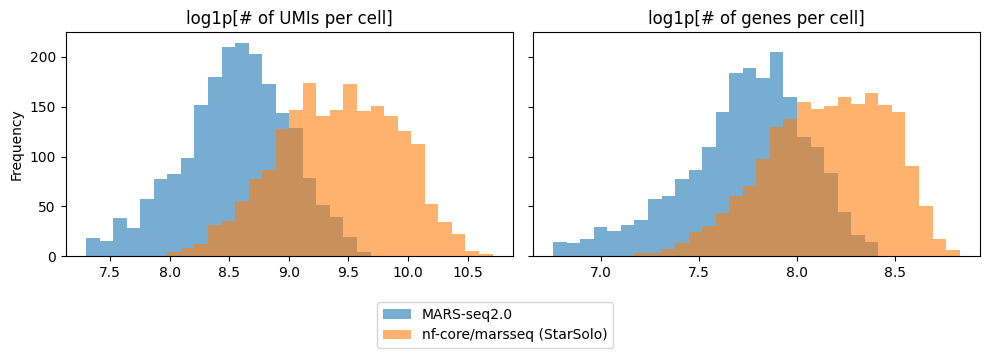

In [153]:
fig, ax = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
pd.DataFrame({
    'MARS-seq2.0': marsseq.obs.log1p_total_counts.values,
    'nf-core/marsseq (StarSolo)': velocity.obs.log1p_total_counts.values
}).plot.hist(bins=30, alpha=0.6, legend=None, title='log1p[# of UMIs per cell]', ax=ax[0])
pd.DataFrame({
    'MARS-seq2.0': marsseq.obs.log1p_n_genes_by_counts.values,
    'nf-core/marsseq (StarSolo)': velocity.obs.log1p_n_genes_by_counts.values
}).plot.hist(bins=30, alpha=0.6, legend=None, title='log1p[# of genes per cell]', ax=ax[1])
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=[0.5,-0.2])
fig.tight_layout()

fig.savefig('../reports/figures/04_bowtie2_vs_starsolo.png', bbox_inches="tight")